# 01 - Exploratory Data Analysis

**Project** Football Betting Integrity Monitor

**Last updated:** 27.05.2026


## Overview

Steps of exploratory data analysis for German Bundesliga, English Premier League, Turkish and Greek top leagues for seasons 17/18 until 25/26.

## 1. Data inspection

In [2]:
# Inspect downloaded files

import pandas as pd
from pathlib import Path

RAW_DIR = Path('../data/raw')

# Load all CSVs into a dict keyed by filename stem (e.g. 'D1_1718')
raw_files = sorted(RAW_DIR.glob('*.csv'))
print(f"Found {len(raw_files)} CSV files")

Found 36 CSV files


In [3]:
# Row counts per league and season

rows_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f)
    rows_data.append({'league': league, 'season': season, 'matches': len(df)})

rows_df = pd.DataFrame(rows_data)
pivot = rows_df.pivot(index='season', columns='league', values='matches')
print(pivot.to_string())

league   D1   E0   G1   T1
season                    
1718    306  380  240  306
1819    306  380  240  306
1920    306  380  240  306
2021    306  380  240  420
2122    306  380  240  380
2223    306  380  240  342
2324    306  380  240  380
2425    306  380  233  342
2526    306  380  236  306


In [4]:
# Column schema audit

schema_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    schema_data.append({
        'league': league,
        'season': season,
        'n_columns': len(df.columns),
        'columns': list(df.columns)
    })

schema_df = pd.DataFrame(schema_data)

# Summary: column counts per league per season
pivot_schema = schema_df.pivot(index='season', columns='league', values='n_columns')
print("Column counts per league/season:")
print(pivot_schema.to_string())

# Flag any seasons that differ from the most common count per league
print("\nAnomalies (seasons with non-standard column count):")
for league in ['D1', 'E0', 'T1', 'G1']:
    subset = schema_df[schema_df['league'] == league]
    most_common = subset['n_columns'].mode()[0]
    anomalies = subset[subset['n_columns'] != most_common]
    if anomalies.empty:
        print(f"  {league}: all seasons consistent ({most_common} columns)")
    else:
        for _, row in anomalies.iterrows():
            print(f"  {league} {row['season']}: {row['n_columns']} columns (expected {most_common})")

Column counts per league/season:
league   D1   E0   G1   T1
season                    
1718     64   65   64   64
1819     61   62   61   61
1920    105  106  105  105
2021    105  106  105  105
2122    105  106  105  105
2223    105  106  105  105
2324    105  106  105  105
2425    119  120  119  119
2526    131  132  131  131

Anomalies (seasons with non-standard column count):
  D1 1718: 64 columns (expected 105)
  D1 1819: 61 columns (expected 105)
  D1 2425: 119 columns (expected 105)
  D1 2526: 131 columns (expected 105)
  E0 1718: 65 columns (expected 106)
  E0 1819: 62 columns (expected 106)
  E0 2425: 120 columns (expected 106)
  E0 2526: 132 columns (expected 106)
  T1 1718: 64 columns (expected 105)
  T1 1819: 61 columns (expected 105)
  T1 2425: 119 columns (expected 105)
  T1 2526: 131 columns (expected 105)
  G1 1718: 64 columns (expected 105)
  G1 1819: 61 columns (expected 105)
  G1 2425: 119 columns (expected 105)
  G1 2526: 131 columns (expected 105)


In [5]:
# Evaluating column consistency accross all files

CORE_COLS = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'B365H', 'B365D', 'B365A',
    'MaxH', 'MaxD', 'MaxA',
    'AvgH', 'AvgD', 'AvgA'
]

print("Core column availability across all files:\n")
missing_any = False

for f in sorted(raw_files):
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    missing = [c for c in CORE_COLS if c not in df.columns]
    if missing:
        print(f"  MISSING in {league}_{season}: {missing}")
        missing_any = True

if not missing_any:
    print("  All 15 core columns present in all 36 files ✓")

Core column availability across all files:

  MISSING in D1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in D1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']


### Note:
**As seasons 17/18 and 18/19 missing crucial data (max and average odds) we are not going to use them and only work with data for 7 seasons between 2019/2020 and 2025/2026**

## 2. Data cleaning and merging

In [6]:
# Clean the data, keep only relevant columns and combine all data into one master dataframe

CORE_COLS = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'B365H', 'B365D', 'B365A',
    'MaxH', 'MaxD', 'MaxA',
    'AvgH', 'AvgD', 'AvgA'
]

TIER_MAP = {
    'D1': 'elite',
    'E0': 'elite',
    'T1': 'mid_tier',
    'G1': 'mid_tier'
}

SEASONS_TO_USE = ["1920", "2021", "2122", "2223", "2324", "2425", "2526"]

frames = []

for f in sorted(Path('../data/raw').glob('*.csv')):
    league, season = f.stem.split('_')

    if season not in SEASONS_TO_USE:
        continue

    df = pd.read_csv(f, usecols=CORE_COLS)
    df['league'] = league
    df['season'] = season
    df['tier']   = TIER_MAP[league]

    frames.append(df)

master = pd.concat(frames, ignore_index=True)

print(f"Total rows:    {len(master):,}")
print(f"Total columns: {len(master.columns)}")
print(f"\nLeague counts:\n{master['league'].value_counts()}")
print(f"\nTier counts:\n{master['tier'].value_counts()}")
print(f"\nSeason counts:\n{master['season'].value_counts().sort_index()}")

Total rows:    8,947
Total columns: 18

League counts:
league
E0    2660
T1    2476
D1    2142
G1    1669
Name: count, dtype: int64

Tier counts:
tier
elite       4802
mid_tier    4145
Name: count, dtype: int64

Season counts:
season
1920    1232
2021    1346
2122    1306
2223    1268
2324    1306
2425    1261
2526    1228
Name: count, dtype: int64


In [7]:
# Fix data types

# Fix date column
master['Date'] = pd.to_datetime(master['Date'], dayfirst=True)

# Ensure score columns are integer
master['FTHG'] = master['FTHG'].astype('Int64')
master['FTAG'] = master['FTAG'].astype('Int64')

# Ensure odds columns are float
odds_cols = ['B365H', 'B365D', 'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
for col in odds_cols:
    master[col] = pd.to_numeric(master[col], errors='coerce')

# Check result
print(master.dtypes)
print(f"\nDate range: {master['Date'].min().date()} → {master['Date'].max().date()}")

Date        datetime64[us]
HomeTeam               str
AwayTeam               str
FTHG                 Int64
FTAG                 Int64
FTR                    str
B365H              float64
B365D              float64
B365A              float64
MaxH               float64
MaxD               float64
MaxA               float64
AvgH               float64
AvgD               float64
AvgA               float64
league                 str
season                 str
tier                   str
dtype: object

Date range: 2019-08-09 → 2026-05-24


In [8]:
# Double-check all column names

master.head(2)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,league,season,tier
0,2019-08-16,Bayern Munich,Hertha,2,2,D,1.14,8.0,15.0,1.25,8.30,17.5,1.18,7.55,15.04,D1,1920,elite
1,2019-08-17,Dortmund,Augsburg,5,1,H,1.20,7.0,13.0,1.25,7.15,17.0,1.22,6.62,13.38,D1,1920,elite


### Column decode

**Match Identity**

- **Date** -  DateDate the match was played

- **HomeTeam** - Team Name of the home team

- **AwayTeam** - Team Name of the away team

**Match Result**

- **FTHG** - Full Time Home Goals - Goals scored by home team
- **FTAG** - Full Time Away Goals - Goals scored by away team
- **FTR** -  Full Time Result - H = Home win, D = Draw, A = Away win

**Bet365 Odds**

- **B365H** - Bet365 Home Win Odds 
- **B365D** - Bet365 Draw Odds
- **B365A** - Bet365 Away Win Odds

**Market Maximum Odds**

- **MaxH** - Maximum Home Win Odds - Best available home win odds across all bookmakers
- **MaxD** - Maximum Draw Odds - Best available draw odds across all bookmakers
- **MaxA** - Maximum Away Win Odds - Best available away win odds across all bookmakers

**Market Average Odds**

- **AvgH** - Average Home Win Odds - Market average home win odds across all bookmakers
- **AvgD** - Average Draw Odds - Market average draw odds across all bookmakers
- **AvgA** - Average Away Win Odds - Market average away win odds across all bookmakers

**Metadata** (added by us)

- **league** - League - CodeD1 = Bundesliga, E0 = EPL, T1 = Turkey, G1 = Greece
- **season** - Season - Codee.g. 1920 = 2019/20 season
- **tier** - League Tier - elite = (Germany, England), mid_tier = (Turkey, Greece)

In [9]:
## Data quality audit

# 1. Null counts
print("=== Null counts ===")
nulls = master.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No nulls found ✓")

# 2. Duplicate rows
dupes = master.duplicated().sum()
print(f"\n=== Duplicate rows: {dupes} ===")

# 3. FTR valid values
print(f"\n=== FTR values ===")
print(master['FTR'].value_counts())

# 4. Odds sanity — all odds should be > 1.0
print("\n=== Odds below 1.0 (invalid) ===")
for col in ['B365H', 'B365D', 'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']:
    bad = (master[col] < 1.0).sum()
    if bad > 0:
        print(f"  {col}: {bad} invalid values")
print("All odds valid ✓") if all((master[col] >= 1.0).all() for col in ['B365H','B365D','B365A','MaxH','MaxD','MaxA','AvgH','AvgD','AvgA']) else None

# 5. Max >= Avg sanity check
print("\n=== Max < Avg anomalies (data errors) ===")
for outcome in ['H', 'D', 'A']:
    bad = (master[f'Max{outcome}'] < master[f'Avg{outcome}']).sum()
    if bad > 0:
        print(f"  Max{outcome} < Avg{outcome}: {bad} rows")
    else:
        print(f"  Max{outcome} >= Avg{outcome} always ✓")

=== Null counts ===
B365H    56
B365D    56
B365A    56
MaxH     30
MaxD     30
MaxA     30
AvgH     30
AvgD     30
AvgA     30
dtype: int64

=== Duplicate rows: 0 ===

=== FTR values ===
FTR
H    3884
A    2818
D    2245
Name: count, dtype: int64

=== Odds below 1.0 (invalid) ===

=== Max < Avg anomalies (data errors) ===
  MaxH >= AvgH always ✓
  MaxD >= AvgD always ✓
  MaxA >= AvgA always ✓


In [10]:
## Evaluating where the nulls are coming from

print("=== Where are the nulls? ===\n")

# B365 nulls by league and season
b365_nulls = master[master['B365H'].isnull()].groupby(['league','season']).size()
print("B365 nulls by league/season:")
print(b365_nulls)

# Max/Avg nulls by league and season
max_nulls = master[master['MaxH'].isnull()].groupby(['league','season']).size()
print("\nMax/Avg nulls by league/season:")
print(max_nulls)

=== Where are the nulls? ===

B365 nulls by league/season:
league  season
G1      1920       3
        2021       4
        2122       2
        2526       8
T1      2021       5
        2223      33
        2324       1
dtype: int64

Max/Avg nulls by league/season:
league  season
G1      2021       1
T1      2223      29
dtype: int64


In [11]:
## Checking if nulls in b365 odds are consistent with nulls in max odds

null_b365 = set(master[master['B365H'].isnull()].index)
null_max = set(master[master['MaxH'].isnull()].index)

print(f"Rows missing B365 only:        {len(null_b365 - null_max)}")
print(f"Rows missing Max/Avg only:      {len(null_max - null_b365)}")
print(f"Rows missing both:              {len(null_b365 & null_max)}")
print(f"Total rows with any null:       {len(null_b365 | null_max)}")

Rows missing B365 only:        26
Rows missing Max/Avg only:      0
Rows missing both:              30
Total rows with any null:       56


In [12]:
## Drop unrecoverable rows that can't be used for our analysis

# Drop rows where Max/Avg are null (no odds data at all - unusable)
before = len(master)
master = master.dropna(subset=['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA'])
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")
print(f"\nRemaining nulls:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Rows dropped: 30
Rows remaining: 8,917

Remaining nulls:
B365H    26
B365D    26
B365A    26
dtype: int64


## 3. Save the master dataset as CSV file

In [13]:
## Save the master dataset as CSV file

PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

master.to_csv(PROCESSED_DIR / 'master.csv', index=False)

print(f"Saved: data/processed/master.csv")
print(f"Shape: {master.shape}")
print(f"\nPreview:")
master.head()

Saved: data/processed/master.csv
Shape: (8917, 18)

Preview:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,league,season,tier
0,2019-08-16,Bayern Munich,Hertha,2,2,D,1.14,8.00,15.00,1.25,8.30,17.50,1.18,7.55,15.04,D1,1920,elite
1,2019-08-17,Dortmund,Augsburg,5,1,H,1.20,7.00,13.00,1.25,7.15,17.00,1.22,6.62,13.38,D1,1920,elite
2,2019-08-17,Freiburg,Mainz,3,0,H,2.25,3.25,3.40,2.26,3.49,3.65,2.20,3.37,3.36,D1,1920,elite
3,2019-08-17,Leverkusen,Paderborn,3,2,H,1.25,6.00,12.00,1.31,6.40,12.25,1.28,5.97,10.27,D1,1920,elite
4,2019-08-17,Werder Bremen,Fortuna Dusseldorf,1,3,A,1.75,3.75,4.75,1.80,4.05,4.95,1.74,3.93,4.57,D1,1920,elite


## 4. Exploratory data analysis

In [14]:
## Set up plotting environment

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Derived columns we'll use throughout EDA
master['implied_prob_sum'] = (
    1/master['B365H'] + 1/master['B365D'] + 1/master['B365A']
)

master['bookmaker_spread_H'] = master['MaxH'] - master['AvgH']
master['bookmaker_spread_D'] = master['MaxD'] - master['AvgD']
master['bookmaker_spread_A'] = master['MaxA'] - master['AvgA']

master['max_spread'] = master[['bookmaker_spread_H','bookmaker_spread_D','bookmaker_spread_A']].max(axis=1)

print("Derived columns added:")
print(['implied_prob_sum', 'bookmaker_spread_H', 'bookmaker_spread_D', 'bookmaker_spread_A', 'max_spread'])
print(f"\nmaster shape: {master.shape}")

Derived columns added:
['implied_prob_sum', 'bookmaker_spread_H', 'bookmaker_spread_D', 'bookmaker_spread_A', 'max_spread']

master shape: (8917, 23)


### 4.1 Match result distribution by league

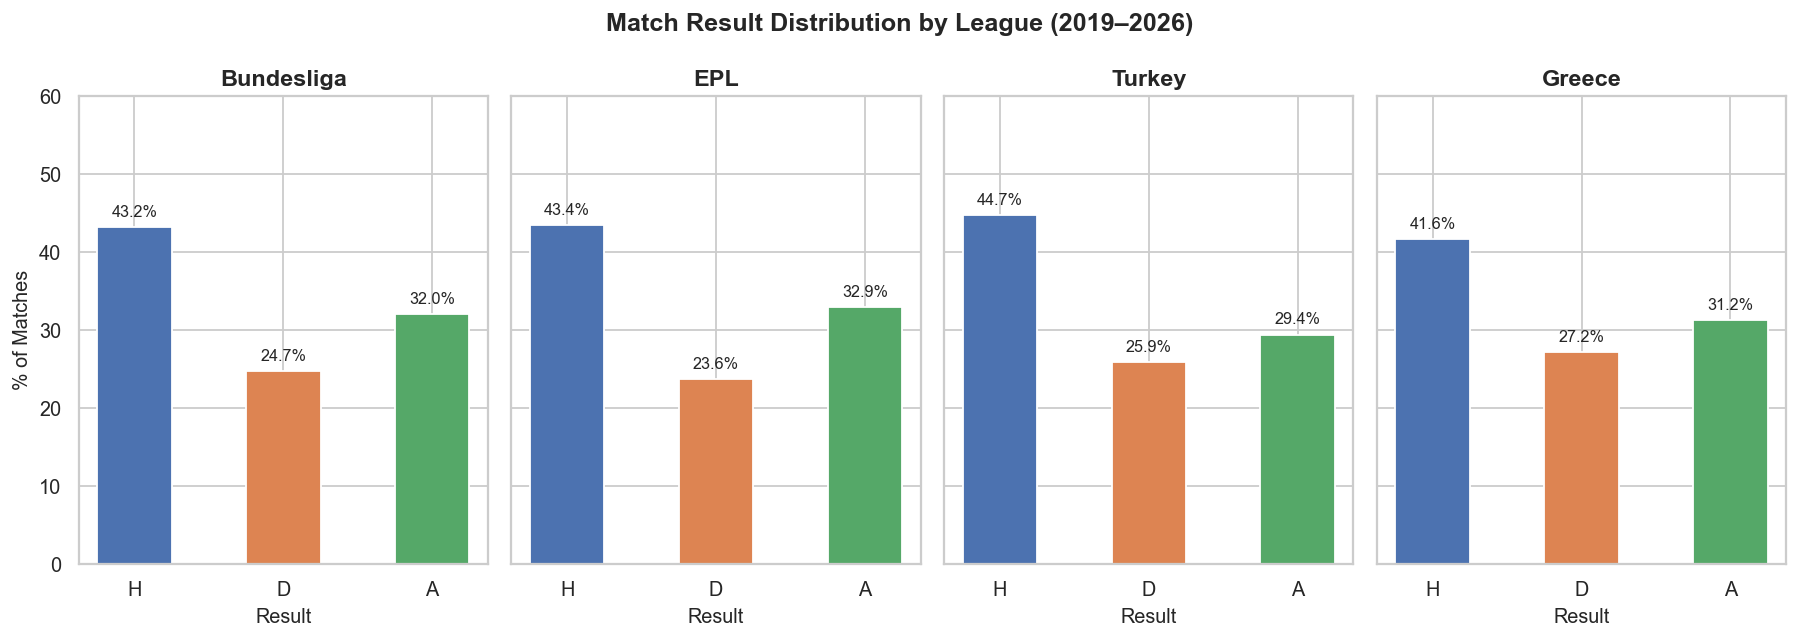

Saved: fig_01_result_distribution.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

leagues = ['D1', 'E0', 'T1', 'G1']
league_names = {
    'D1': 'Bundesliga',
    'E0': 'EPL',
    'T1': 'Turkey',
    'G1': 'Greece'
}
colors = {'H': '#4C72B0', 'D': '#DD8452', 'A': '#55A868'}

for ax, league in zip(axes, leagues):
    data = master[master['league'] == league]['FTR'].value_counts(normalize=True) * 100
    data = data.reindex(['H', 'D', 'A'])
    bars = ax.bar(data.index, data.values, color=[colors[k] for k in data.index], width=0.5)
    ax.set_title(league_names[league], fontweight='bold')
    ax.set_xlabel('Result')
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('% of Matches')
fig.suptitle('Match Result Distribution by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_01_result_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: fig_01_result_distribution.png")


**Note:** 
All four leagues show the classic European football pattern — home wins ~42–45%, draws ~24–27%, away wins ~29–33%. The variation between leagues is minimal (< 3pp on any outcome).



**Baseline legitimacy check:** If one league showed dramatically skewed results (e.g. 60% home wins in Greece), that alone would be a red flag. The fact that all four leagues are consistent tells us:

- Result distributions are not where the manipulation signal hides
- We won't find integrity anomalies by looking at scorelines alone
- This validates our approach of looking at odds behaviour instead — bookmaker spreads, implied probabilities, and market disagreement are the right signals to chase



**Observations:** 
- Result distributions are broadly consistent across all four leagues (H: 42–45%, D: 24–27%, A: 29–33%). 

- This confirms that match outcome patterns alone are insufficient to detect integrity anomalies — validating the odds-based approach used in this project. 

- Turkey shows the strongest home advantage bias (44.7% H, 29.4% A).


### 4.2 Bookmaker spread by tier (H1 visual).

Max − Avg odds spread per match, comparing elite vs mid-tier leagues.

A higher spread indicates greater bookmaker disagreement — a key integrity signal.

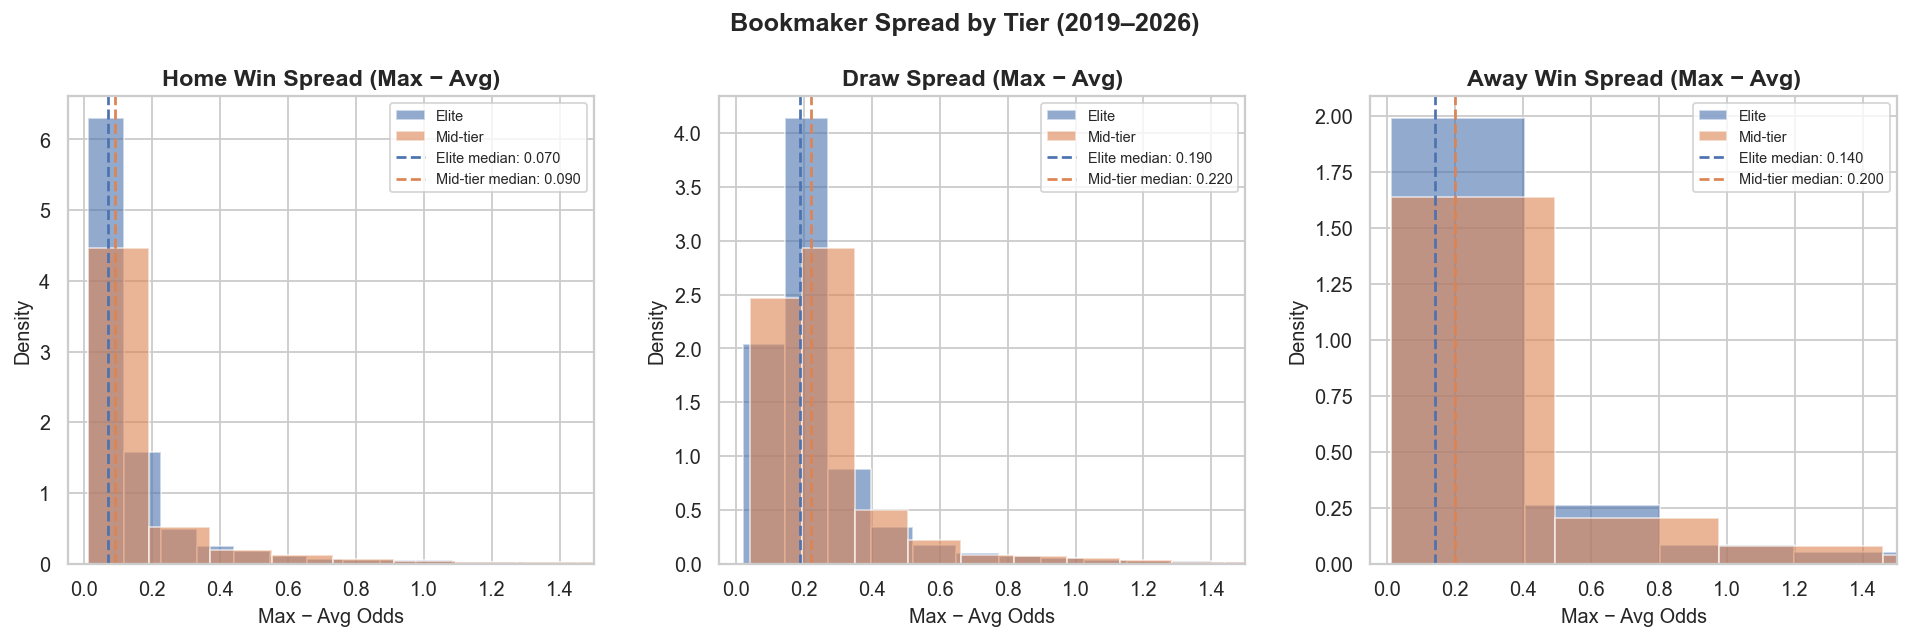

=== Bookmaker Spread Summary (median) ===

Home Win:
  Elite:    0.0700
  Mid-tier: 0.0900
  Mid-tier is +28.6% wider than elite

Draw:
  Elite:    0.1900
  Mid-tier: 0.2200
  Mid-tier is +15.8% wider than elite

Away Win:
  Elite:    0.1400
  Mid-tier: 0.2000
  Mid-tier is +42.9% wider than elite



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    elite_data = master[master['tier'] == 'elite'][col].dropna()
    mid_data = master[master['tier'] == 'mid_tier'][col].dropna()
    
    ax.hist(elite_data, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
    ax.hist(mid_data, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
    
    ax.axvline(elite_data.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
               label=f'Elite median: {elite_data.median():.3f}')
    ax.axvline(mid_data.median(), color='#DD8452', linestyle='--', linewidth=1.5,
               label=f'Mid-tier median: {mid_data.median():.3f}')
    
    ax.set_title(f'{outcome_labels[outcome]} Spread (Max − Avg)', fontweight='bold')
    ax.set_xlabel('Max − Avg Odds')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.5)

fig.suptitle('Bookmaker Spread by Tier (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_02_bookmaker_spread_by_tier.png', bbox_inches='tight')
plt.show()

# Print summary stats
print("=== Bookmaker Spread Summary (median) ===\n")
for outcome in outcomes:
    col = f'bookmaker_spread_{outcome}'
    elite_med = master[master['tier'] == 'elite'][col].median()
    mid_med = master[master['tier'] == 'mid_tier'][col].median()
    diff_pct = ((mid_med - elite_med) / elite_med) * 100
    print(f"{outcome_labels[outcome]}:")
    print(f"  Elite:    {elite_med:.4f}")
    print(f"  Mid-tier: {mid_med:.4f}")
    print(f"  Mid-tier is {diff_pct:+.1f}% wider than elite\n")

**Observations (H1):** 

Mid-tier leagues (Turkey, Greece) show systematically wider bookmaker spreads than elite leagues (Bundesliga, EPL) across all three match outcomes. 

The away win spread is 42.9% wider in mid-tier leagues — the largest gap observed. 

Elite distributions are tightly concentrated near zero with minimal tail risk, while mid-tier distributions show significant right-skew with extreme outliers exceeding 1.0 odds units. 

This pattern is consistent with lower bookmaker confidence in mid-tier markets and forms the primary visual evidence for H1.

### 4.3 Implied probability sum by league (overround analysis)

The sum of implied probabilities (1/H + 1/D + 1/A) across all three outcomes should sum to >1.0.

The excess above 1.0 is the bookmaker's margin (overround). **Higher overround = bookmaker charging more = less efficient market.**

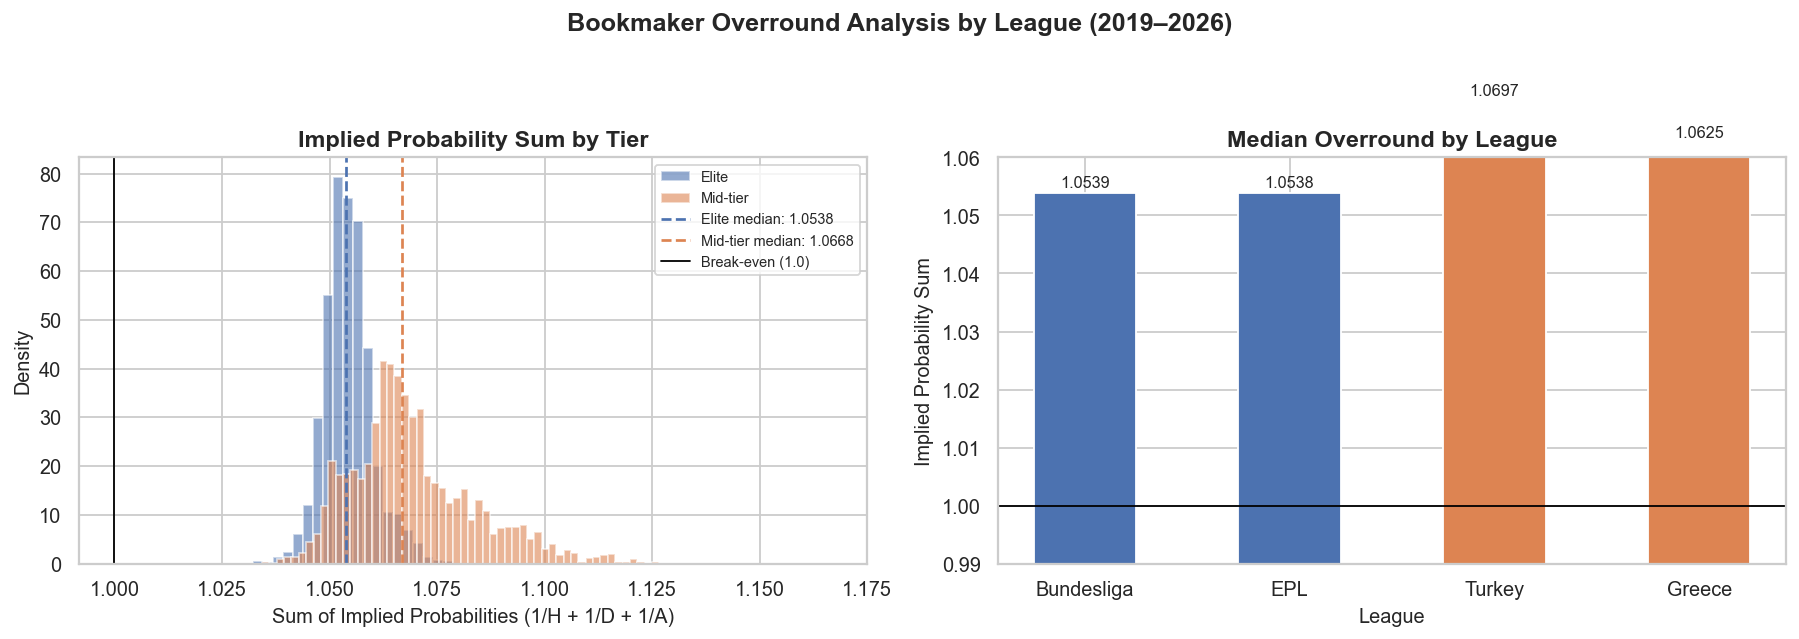

=== Overround Summary ===

Bundesliga: median=1.0539 → bookmaker margin=5.39%
EPL: median=1.0538 → bookmaker margin=5.38%
Turkey: median=1.0697 → bookmaker margin=6.97%
Greece: median=1.0625 → bookmaker margin=6.25%


In [17]:
# Drop rows where B365 nulls exist for this analysis
ips_data = master.dropna(subset=['implied_prob_sum'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — distribution by tier
elite_ips = ips_data[ips_data['tier'] == 'elite']['implied_prob_sum']
mid_ips = ips_data[ips_data['tier'] == 'mid_tier']['implied_prob_sum']

axes[0].hist(elite_ips, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
axes[0].hist(mid_ips, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
axes[0].axvline(elite_ips.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
                label=f'Elite median: {elite_ips.median():.4f}')
axes[0].axvline(mid_ips.median(), color='#DD8452', linestyle='--', linewidth=1.5,
                label=f'Mid-tier median: {mid_ips.median():.4f}')
axes[0].axvline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[0].set_title('Implied Probability Sum by Tier', fontweight='bold')
axes[0].set_xlabel('Sum of Implied Probabilities (1/H + 1/D + 1/A)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Chart 2 — median overround by league
overround_by_league = ips_data.groupby('league')['implied_prob_sum'].median()
overround_by_league = overround_by_league.reindex(['D1', 'E0', 'T1', 'G1'])
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
bars = axes[1].bar(
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    overround_by_league.values,
    color=colors, width=0.5
)
axes[1].axhline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[1].set_title('Median Overround by League', fontweight='bold')
axes[1].set_xlabel('League')
axes[1].set_ylabel('Implied Probability Sum')
axes[1].set_ylim(0.99, 1.06)
for bar, val in zip(bars, overround_by_league.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Bookmaker Overround Analysis by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_03_implied_probability_sum.png', bbox_inches='tight')
plt.show()

# Summary stats
print("=== Overround Summary ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    med = ips_data[ips_data['league'] == league]['implied_prob_sum'].median()
    margin_pct = (med - 1.0) * 100
    print(f"{name}: median={med:.4f} → bookmaker margin={margin_pct:.2f}%")

**Observation (Overround):** Mid-tier leagues charge systematically higher bookmaker margins than elite leagues. 

Turkey (6.97%) and Greece (6.25%) both significantly exceed Bundesliga (5.39%) and EPL (5.38%). 

The mid-tier distribution is wider and right-skewed, with extreme outliers approaching **17–18%** margin — values that have no legitimate explanation in an efficient market and will be primary targets for the anomaly detector.

### 4.4 Bookmaker spread by league (individual league breakdown)

Drilling into the spread by individual league to separate Turkey vs Greece within the mid-tier.

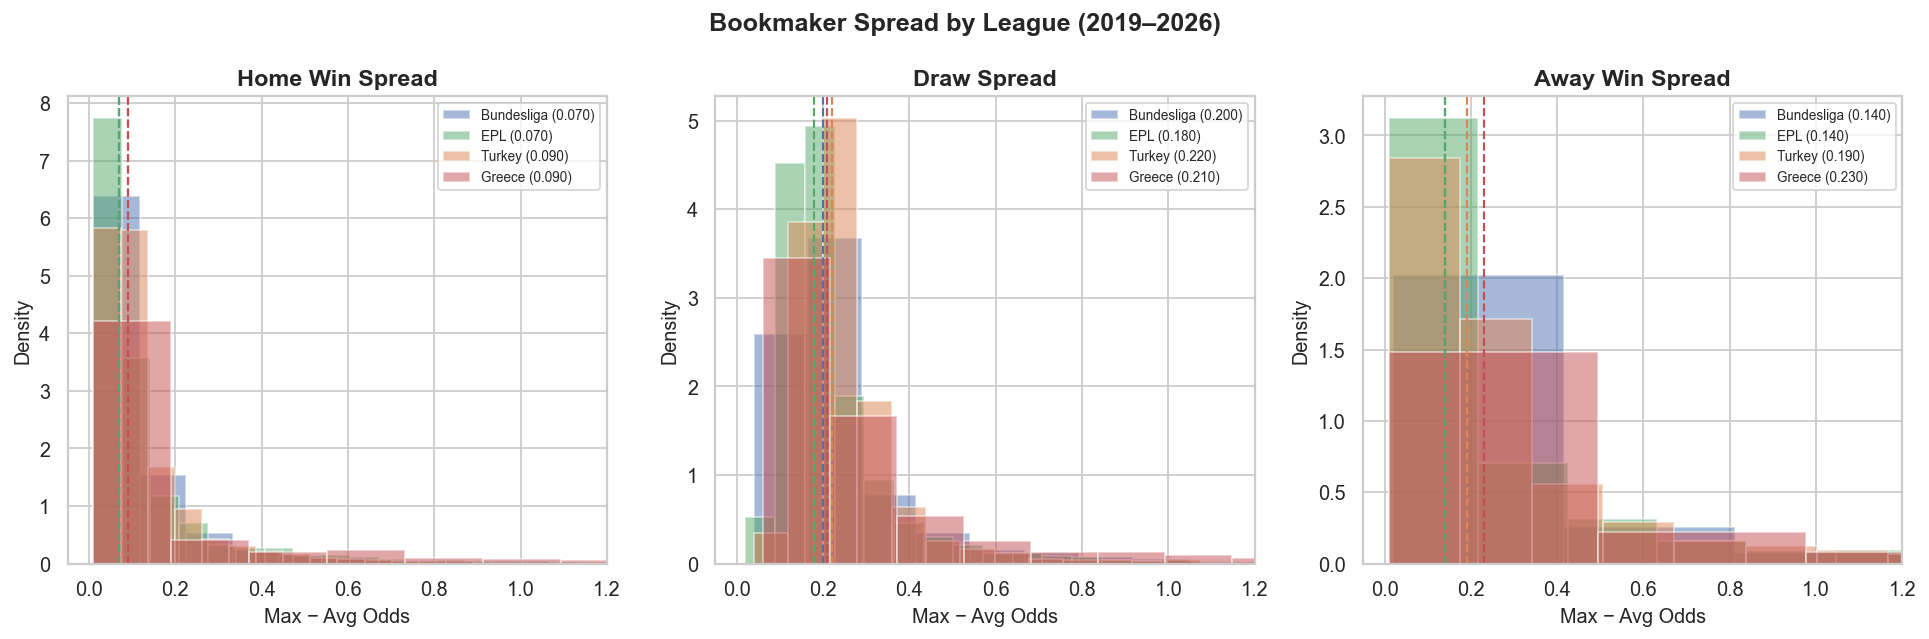

=== Median Spread by League ===

League           Home     Draw     Away     Mean
--------------------------------------------
Bundesliga     0.0700   0.2000   0.1400   0.1367
EPL            0.0700   0.1800   0.1400   0.1300
Turkey         0.0900   0.2200   0.1900   0.1667
Greece         0.0900   0.2100   0.2300   0.1767


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
league_colors = {
    'D1': '#4C72B0',
    'E0': '#55A868',
    'T1': '#DD8452',
    'G1': '#C44E52'
}
league_names = {
    'D1': 'Bundesliga',
    'E0': 'EPL',
    'T1': 'Turkey',
    'G1': 'Greece'
}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    medians = {}
    for league in ['D1', 'E0', 'T1', 'G1']:
        data = master[master['league'] == league][col].dropna()
        medians[league] = data.median()
        ax.hist(data, bins=60, alpha=0.5, label=f"{league_names[league]} ({data.median():.3f})",
                color=league_colors[league], density=True)
        ax.axvline(data.median(), color=league_colors[league], linestyle='--', linewidth=1.2)

    ax.set_title(f'{outcome_labels[outcome]} Spread', fontweight='bold')
    ax.set_xlabel('Max − Avg Odds')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.05, 1.2)
    ax.legend(fontsize=7.5)

fig.suptitle('Bookmaker Spread by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_04_spread_by_league.png', bbox_inches='tight')
plt.show()

# Summary table
print("=== Median Spread by League ===\n")
print(f"{'League':<12} {'Home':>8} {'Draw':>8} {'Away':>8} {'Mean':>8}")
print("-" * 44)
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    h = master[master['league'] == league]['bookmaker_spread_H'].median()
    d = master[master['league'] == league]['bookmaker_spread_D'].median()
    a = master[master['league'] == league]['bookmaker_spread_A'].median()
    print(f"{name:<12} {h:>8.4f} {d:>8.4f} {a:>8.4f} {(h+d+a)/3:>8.4f}")

**Observation (League-level spread):** Individual league analysis reveals EPL as the most efficient market (mean spread 0.130), followed by Bundesliga (0.137), Turkey (0.167), and Greece (0.177). 

Greece's away win spread (0.230) is 64% wider than EPL — the largest single gap observed across all leagues and outcomes. 

This ranking is consistent with historical integrity records and suggests Greece warrants the closest scrutiny in the anomaly detection phase.

### 4.5 Seasonal trends in bookmaker spread

Tracking how bookmaker spread evolves across seasons for each league.
    
A downward trend = market becoming more efficient over time.

A spike in a specific season = potential integrity event or structural change.

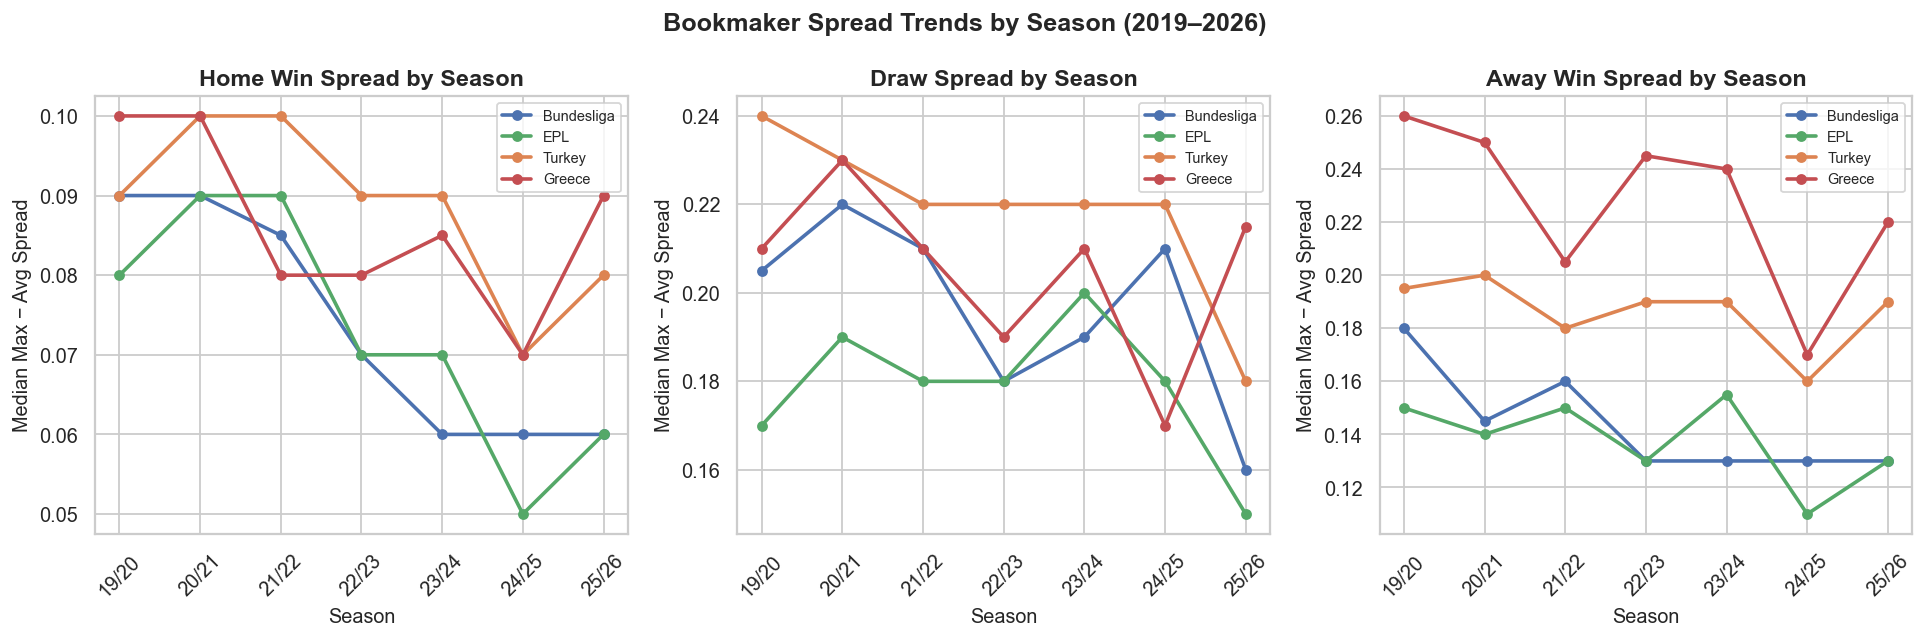

=== Median Away Win Spread by Season (most informative) ===

Season    Bundesliga         EPL      Turkey      Greece
--------------------------------------------------------
19/20         0.1800      0.1500      0.1950      0.2600
20/21         0.1450      0.1400      0.2000      0.2500
21/22         0.1600      0.1500      0.1800      0.2050
22/23         0.1300      0.1300      0.1900      0.2450
23/24         0.1300      0.1550      0.1900      0.2400
24/25         0.1300      0.1100      0.1600      0.1700
25/26         0.1300      0.1300      0.1900      0.2200


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
season_labels = ['19/20', '20/21', '21/22', '22/23', '23/24', '24/25', '25/26']

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    for league, name, color in zip(
        ['D1', 'E0', 'T1', 'G1'],
        ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
        ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
    ):
        season_medians = (
            master[master['league'] == league]
            .groupby('season')[col]
            .median()
            .reindex(['1920','2021','2122','2223','2324','2425','2526'])
        )
        ax.plot(season_labels, season_medians.values, marker='o', 
                label=name, color=color, linewidth=2, markersize=5)

    ax.set_title(f'{outcome_labels[outcome]} Spread by Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Median Max − Avg Spread')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Bookmaker Spread Trends by Season (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_05_seasonal_trends.png', bbox_inches='tight')
plt.show()

# Print the numbers
print("=== Median Away Win Spread by Season (most informative) ===\n")
print(f"{'Season':<8}", end='')
for name in ['Bundesliga', 'EPL', 'Turkey', 'Greece']:
    print(f"{name:>12}", end='')
print()
print("-" * 56)

for season, label in zip(['1920','2021','2122','2223','2324','2425','2526'], season_labels):
    print(f"{label:<8}", end='')
    for league in ['D1', 'E0', 'T1', 'G1']:
        val = master[(master['league'] == league) & 
                     (master['season'] == season)]['bookmaker_spread_A'].median()
        print(f"{val:>12.4f}", end='')
    print()

**Observation (Seasonal Trends):** Elite leagues show consistent efficiency improvements over 7 seasons — EPL's away win spread fell from 0.150 to 0.110 by 24/25. 

Mid-tier leagues show no meaningful improvement — Turkey's away win spread (0.195 → 0.190) and Greece's (0.260 → 0.220) remain structurally elevated throughout the entire period. 

Greece's resistance to market efficiency improvement is the most notable pattern, with a brief dip in 24/25 immediately reverting in 25/26. 

The 19/20 Greece spike (0.260) coincides with the COVID-interrupted season and warrants contextual flagging.

### 4.6 End-of-season spread concentration (H4 visual)

Testing whether bookmaker spreads are higher in the final matches of the season.

Matches are grouped by their position in the season (matchday quintile).

Higher spread in the final quintile = potential integrity signal.

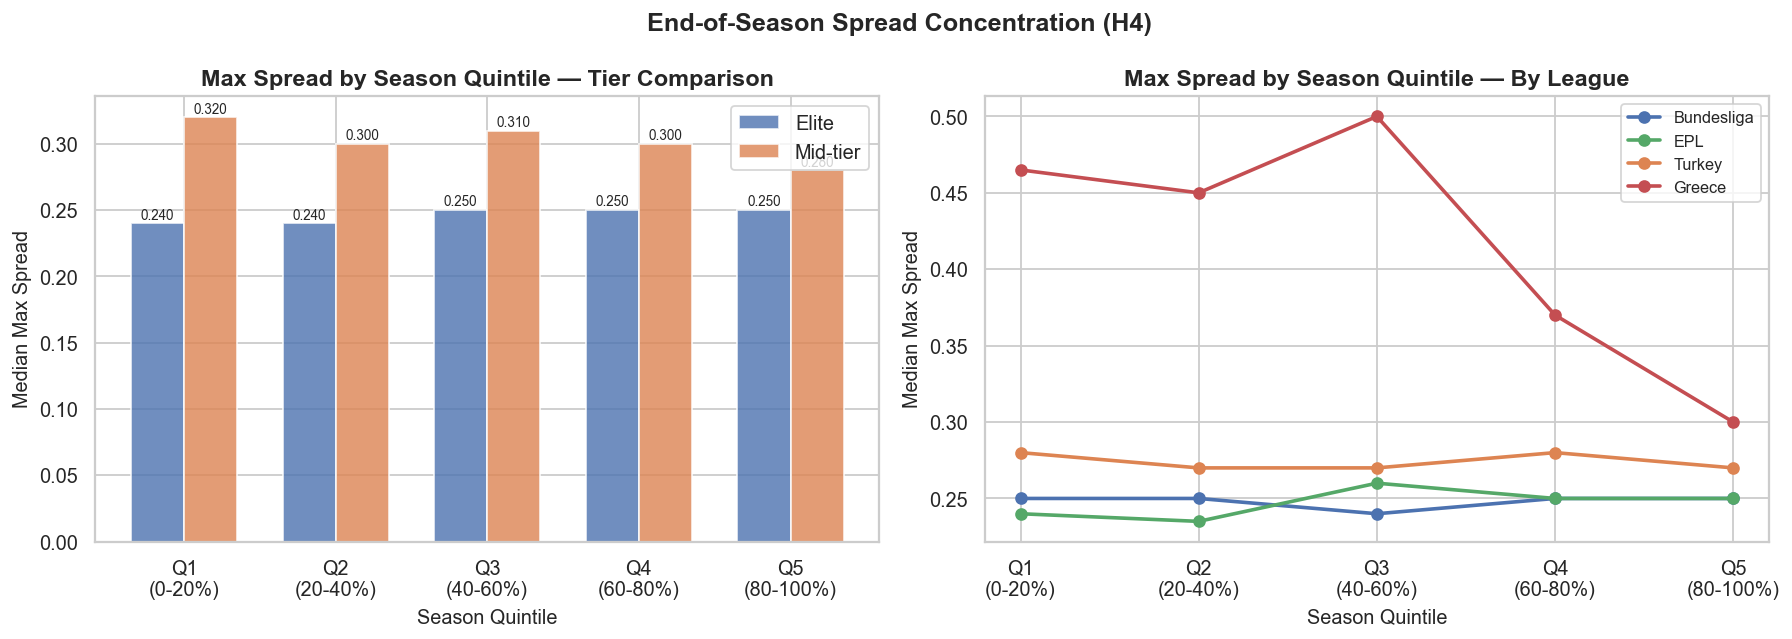

=== Median Max Spread by Quintile ===

Quintile       Bundesliga      EPL     Turkey     Greece
------------------------------------------------------
Q1              0.2500    0.2400    0.2800    0.4650
Q2              0.2500    0.2350    0.2700    0.4500
Q3              0.2400    0.2600    0.2700    0.5000
Q4              0.2500    0.2500    0.2800    0.3700
Q5              0.2500    0.2500    0.2700    0.3000

=== Q5 vs Q1 change (end vs start of season) ===

Bundesliga  : Q1=0.2500 → Q5=0.2500  (+0.0%)
EPL         : Q1=0.2400 → Q5=0.2500  (+4.2%)
Turkey      : Q1=0.2800 → Q5=0.2700  (-3.6%)
Greece      : Q1=0.4650 → Q5=0.3000  (-35.5%)


In [20]:
# Calculate matchday position within each league-season
master['match_date'] = pd.to_datetime(master['Date'])

# Rank matches within each league-season by date
master['match_rank'] = master.groupby(['league', 'season'])['match_date'].rank(method='first')
master['season_size'] = master.groupby(['league', 'season'])['match_date'].transform('count')
master['season_pct'] = master['match_rank'] / master['season_size']

# Assign quintile (1=first 20% of season, 5=last 20% of season)
master['season_quintile'] = pd.cut(
    master['season_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — max_spread by quintile, elite vs mid-tier
quintile_tier = master.groupby(['season_quintile', 'tier'])['max_spread'].median().unstack()

x = range(5)
width = 0.35
quintile_labels = ['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']

bars1 = axes[0].bar([i - width/2 for i in x], quintile_tier['elite'], 
                     width, label='Elite', color='#4C72B0', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x], quintile_tier['mid_tier'], 
                     width, label='Mid-tier', color='#DD8452', alpha=0.8)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_title('Max Spread by Season Quintile — Tier Comparison', fontweight='bold')
axes[0].set_xlabel('Season Quintile')
axes[0].set_ylabel('Median Max Spread')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(quintile_labels)
axes[0].legend()

# Chart 2 — max_spread by quintile, all 4 leagues
quintile_league = master.groupby(['season_quintile', 'league'])['max_spread'].median().unstack()

for league, name, color in zip(
    ['D1', 'E0', 'T1', 'G1'],
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
):
    axes[1].plot(quintile_labels, quintile_league[league].values,
                 marker='o', label=name, color=color, linewidth=2, markersize=6)

axes[1].set_title('Max Spread by Season Quintile — By League', fontweight='bold')
axes[1].set_xlabel('Season Quintile')
axes[1].set_ylabel('Median Max Spread')
axes[1].legend(fontsize=9)

fig.suptitle('End-of-Season Spread Concentration (H4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_06_end_of_season_concentration.png', bbox_inches='tight')
plt.show()

# Print summary table
print("=== Median Max Spread by Quintile ===\n")
print(f"{'Quintile':<12} {'Bundesliga':>12} {'EPL':>8} {'Turkey':>10} {'Greece':>10}")
print("-" * 54)
for q, label in zip(quintile_league.index, ['Q1','Q2','Q3','Q4','Q5']):
    print(f"{label:<12}", end='')
    for league in ['D1', 'E0', 'T1', 'G1']:
        print(f"{quintile_league.loc[q, league]:>10.4f}", end='')
    print()

# Q5 vs Q1 change
print("\n=== Q5 vs Q1 change (end vs start of season) ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    q1 = quintile_league.loc['Q1\n(0-20%)', league]
    q5 = quintile_league.loc['Q5\n(80-100%)', league]
    change = ((q5 - q1) / q1) * 100
    print(f"{name:<12}: Q1={q1:.4f} → Q5={q5:.4f}  ({change:+.1f}%)")

**Observation (H4):** Contrary to expectations, end-of-season spread concentration is not observed in mid-tier leagues. 

Greece shows the opposite pattern — spreads peak in Q3 (mid-season, 0.500) and decline sharply toward Q5 (0.300), a -35.5% drop from Q1. 

Elite leagues show no meaningful seasonal variation. 

The Greek Super League's split-round format (top 6 vs bottom 10 in final phase) is a likely structural explanation. 

H4 is not supported in its original form — seasonal position alone is insufficient as an integrity signal. 

The anomaly detection model will treat season quintile as a contextual feature rather than a directional predictor.

## 5. EDA Summary

Summary of all findings from exploratory analysis and what feeds into feature engineering.

### 5.1 Key findings

| # | Finding | Hypothesis | Direction |
|---|---|---|---|
| 1 | Mid-tier leagues have 16–43% wider bookmaker spreads than elite | H1 | ✅ Supported |
| 2 | Mid-tier bookmaker margins are 15–29% higher than elite (Turkey 6.97%, Greece 6.25% vs EPL 5.38%) | H1 | ✅ Supported |
| 3 | Greece is the least efficient market — away win spread 64% wider than EPL | H1 | ✅ Supported |
| 4 | Elite leagues show consistent efficiency improvements over 7 seasons — mid-tier do not | H1 | ✅ Supported |
| 5 | Result distributions are consistent across all leagues — outcome patterns alone cannot detect manipulation | — | ℹ️ Baseline check |
| 6 | Greece's spreads peak in Q3 (mid-season) and drop toward end of season (-35.5%) | H4 | ❌ Not supported as framed |
| 7 | Turkey shows no meaningful seasonal spread pattern | H4 | ❌ Not supported as framed |

In [21]:
# Save enriched master with all EDA-derived columns
master.to_csv('../data/processed/master_enriched.csv', index=False)

print("Saved: data/processed/master_enriched.csv")
print(f"Shape: {master.shape}")
print(f"\nColumns added during EDA:")
new_cols = ['implied_prob_sum', 'bookmaker_spread_H', 'bookmaker_spread_D', 
            'bookmaker_spread_A', 'max_spread', 'match_rank', 'season_size',
            'season_pct', 'season_quintile']
print(new_cols)

Saved: data/processed/master_enriched.csv
Shape: (8917, 28)

Columns added during EDA:
['implied_prob_sum', 'bookmaker_spread_H', 'bookmaker_spread_D', 'bookmaker_spread_A', 'max_spread', 'match_rank', 'season_size', 'season_pct', 'season_quintile']


## 6. Additional findings 

Additional analysis of bookmakers behavior and game results to see if there are any anomalies.

### 6.1 Bookmaker accuracy - does the favourite win? (withoun normalization)

For each match, identify the bookmaker's favourite (lowest odds = highest implied probability).

Compare predicted favourite vs actual result across leagues and tiers.



In [22]:
# Identify favourite for each match
def get_favourite(row):
    probs = {
        'H': 1 / row['B365H'],
        'D': 1 / row['B365D'],
        'A': 1 / row['B365A']
    }
    return max(probs, key=probs.get)

# Only use rows where B365 is available
accuracy_df = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
accuracy_df['favourite'] = accuracy_df.apply(get_favourite, axis=1)
accuracy_df['favourite_won'] = accuracy_df['favourite'] == accuracy_df['FTR']

# Favourite type distribution
print("=== Favourite type distribution ===")
print(accuracy_df['favourite'].value_counts())
print(f"\nOverall favourite win rate: {accuracy_df['favourite_won'].mean()*100:.1f}%")

=== Favourite type distribution ===
favourite
H    5945
A    2942
D       4
Name: count, dtype: int64

Overall favourite win rate: 53.1%


In [23]:
# Finding 4 games where draw was the favorite per bookmakers

draw_favs = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
draw_favs['favourite'] = draw_favs.apply(get_favourite, axis=1)
draw_favs = draw_favs[draw_favs['favourite'] == 'D']

cols = ['Date', 'HomeTeam', 'AwayTeam', 'league', 'season', 
        'B365H', 'B365D', 'B365A', 'FTR']
print(draw_favs[cols].to_string(index=False))

      Date         HomeTeam         AwayTeam league season  B365H  B365D  B365A FTR
2023-05-06         Giannina Asteras Tripolis     G1   2223    2.6   2.25   4.00   H
2024-04-27 Asteras Tripolis        OFI Crete     G1   2324    2.8   2.63   3.20   D
2024-05-18      Kayserispor        Konyaspor     T1   2324    3.0   2.40   3.10   D
2024-05-26        Konyaspor      Galatasaray     T1   2324    9.0   1.95   2.05   A


### Favorite winrate chart

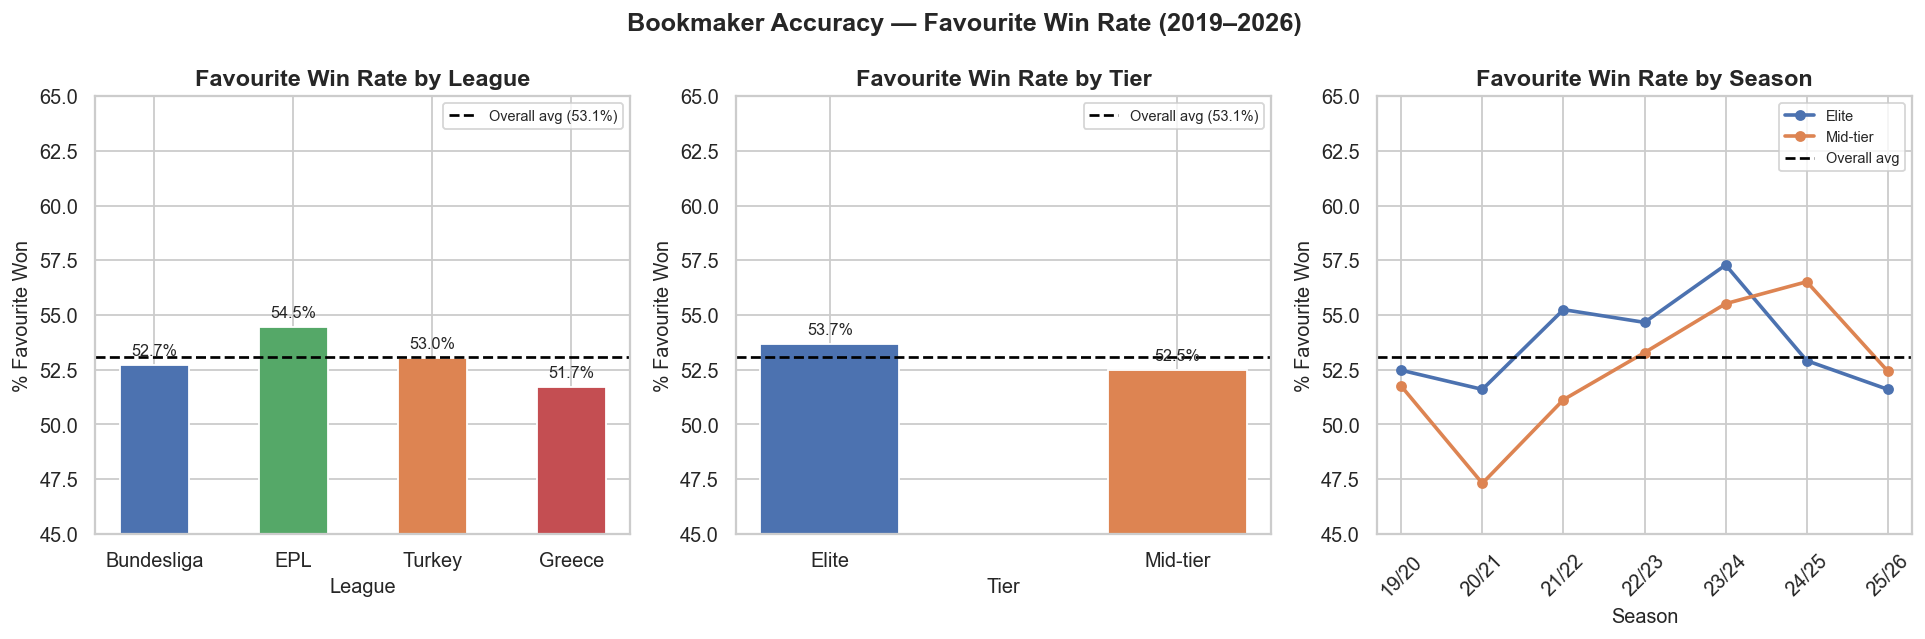

=== Favourite Win Rate by League ===

Bundesliga  : 52.7% (1129/2142 matches)
EPL         : 54.5% (1449/2660 matches)
Turkey      : 53.0% (1291/2435 matches)
Greece      : 51.7% (853/1650 matches)

=== By favourite type ===

Bundesliga   favourite=H: 53.6% (1393 matches)
EPL          favourite=H: 55.6% (1673 matches)
Turkey       favourite=H: 53.6% (1725 matches)
Greece       favourite=H: 50.5% (1154 matches)

Bundesliga   favourite=A: 51.1% (749 matches)
EPL          favourite=A: 52.5% (987 matches)
Turkey       favourite=A: 51.5% (710 matches)
Greece       favourite=A: 54.4% (496 matches)



In [24]:
# Remove the 4 draw-favourite matches
accuracy_df = accuracy_df[accuracy_df['favourite'] != 'D']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — favourite win rate by league
win_rate_league = accuracy_df.groupby('league')['favourite_won'].mean() * 100
win_rate_league = win_rate_league.reindex(['D1', 'E0', 'T1', 'G1'])
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

bars = axes[0].bar(
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    win_rate_league.values,
    color=colors, width=0.5
)
axes[0].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg (53.1%)')
axes[0].set_ylim(45, 65)
axes[0].set_title('Favourite Win Rate by League', fontweight='bold')
axes[0].set_xlabel('League')
axes[0].set_ylabel('% Favourite Won')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, win_rate_league.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 2 — favourite win rate by tier
win_rate_tier = accuracy_df.groupby('tier')['favourite_won'].mean() * 100
bars2 = axes[1].bar(
    ['Elite', 'Mid-tier'],
    [win_rate_tier['elite'], win_rate_tier['mid_tier']],
    color=['#4C72B0', '#DD8452'], width=0.4
)
axes[1].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg (53.1%)')
axes[1].set_ylim(45, 65)
axes[1].set_title('Favourite Win Rate by Tier', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('% Favourite Won')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, [win_rate_tier['elite'], win_rate_tier['mid_tier']]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 3 — favourite win rate by season and tier
win_rate_season = accuracy_df.groupby(['season', 'tier'])['favourite_won'].mean() * 100
season_labels = ['19/20', '20/21', '21/22', '22/23', '23/24', '24/25', '25/26']

for tier, color, label in zip(
    ['elite', 'mid_tier'],
    ['#4C72B0', '#DD8452'],
    ['Elite', 'Mid-tier']
):
    vals = win_rate_season.xs(tier, level='tier').reindex(
        ['1920','2021','2122','2223','2324','2425','2526']
    )
    axes[2].plot(season_labels, vals.values, marker='o',
                 color=color, label=label, linewidth=2, markersize=5)

axes[2].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
axes[2].set_title('Favourite Win Rate by Season', fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('% Favourite Won')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(45, 65)

fig.suptitle('Bookmaker Accuracy — Favourite Win Rate (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_07_favourite_win_rate.png', bbox_inches='tight')
plt.show()

# Summary stats
print("=== Favourite Win Rate by League ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    rate = accuracy_df[accuracy_df['league'] == league]['favourite_won'].mean() * 100
    total = len(accuracy_df[accuracy_df['league'] == league])
    correct = accuracy_df[(accuracy_df['league'] == league) & 
                          (accuracy_df['favourite_won'])].shape[0]
    print(f"{name:<12}: {rate:.1f}% ({correct}/{total} matches)")

print(f"\n=== By favourite type ===\n")
for fav in ['H', 'A']:
    for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
        subset = accuracy_df[(accuracy_df['league'] == league) & 
                             (accuracy_df['favourite'] == fav)]
        if len(subset) > 0:
            rate = subset['favourite_won'].mean() * 100
            print(f"{name:<12} favourite={fav}: {rate:.1f}% ({len(subset)} matches)")
    print()

**Observation (Bookmaker Accuracy):** EPL is the most accurately priced league (54.5% favourite win rate) while Greece is the least accurate (51.7%). 

The most striking finding is Greece's inverted home/away accuracy — home favourites win only 50.5% of the time (near random) while away favourites win 54.4%, the opposite pattern to all other leagues. This anomaly is consistent with weaker or less predictable home advantage in Greece and warrants further investigation in the anomaly detection phase. 

The COVID-affected 20/21 season shows a severe accuracy drop in mid-tier leagues (47.5%), confirming behind-closed-doors matches as a significant confound requiring contextual handling.

### 6.2 Market efficiency — calibration, favourite-longshot bias, and draw mispricing

Three linked analyses using normalised implied probabilities **(margin removed)**:
1. **Calibration** — do implied probabilities match realised frequencies?
2. **Favourite-longshot bias** — are longshots systematically overbet vs favourites?
3. **Draw mispricing** — does the market under/over-price draws per league?

#### Methodology note: implied probability normalisation

Raw implied probabilities (1/odds) include the bookmaker's margin and sum to >1.0.
To compare predicted vs realised outcomes, we strip the margin by **multiplicative
normalisation** — dividing each outcome's implied probability by the row total so the
three outcomes sum to 1.0.

**Assumption:** this spreads the margin *proportionally* across all three outcomes.
Real bookmakers typically load disproportionate margin onto longshots (the favourite-
longshot bias), so proportional normalisation may leave a small residual inflation on
high-odds outcomes. As a result, part of any measured favourite-longshot bias could be
partially attributable to the normalisation method rather than purely to bettor behaviour.

**Alternatives considered:** additive normalisation (flat margin per outcome) and Shin's
method (models margin as arising from insider trading, the academic standard for integrity
analysis). Multiplicative normalisation is used here for transparency and interpretability;
Shin's method is noted as a robustness check for future work.

In [25]:
# Build long-format frame: each match -> 3 rows (H, D, A) with normalised implied prob
eff = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()

rows = []
for _, r in eff.iterrows():
    raw = {'H': 1/r['B365H'], 'D': 1/r['B365D'], 'A': 1/r['B365A']}
    total = sum(raw.values())  # the overround
    for outcome in ['H', 'D', 'A']:
        rows.append({
            'league': r['league'],
            'tier': r['tier'],
            'season': r['season'],
            'outcome': outcome,
            'implied_norm': raw[outcome] / total,   # margin removed
            'occurred': int(r['FTR'] == outcome)
        })

long_df = pd.DataFrame(rows)
print(f"Long-format rows: {len(long_df):,} (should be ~{len(eff)*3:,})")
print(f"\nMean normalised implied prob by outcome:")
print(long_df.groupby('outcome')['implied_norm'].mean().round(4))
print(f"\nActual occurrence rate by outcome:")
print(long_df.groupby('outcome')['occurred'].mean().round(4))

Long-format rows: 26,673 (should be ~26,673)

Mean normalised implied prob by outcome:
outcome
A    0.3162
D    0.2437
H    0.4401
Name: implied_norm, dtype: float64

Actual occurrence rate by outcome:
outcome
A    0.3143
D    0.2519
H    0.4338
Name: occurred, dtype: float64


### Market accuracy calibration

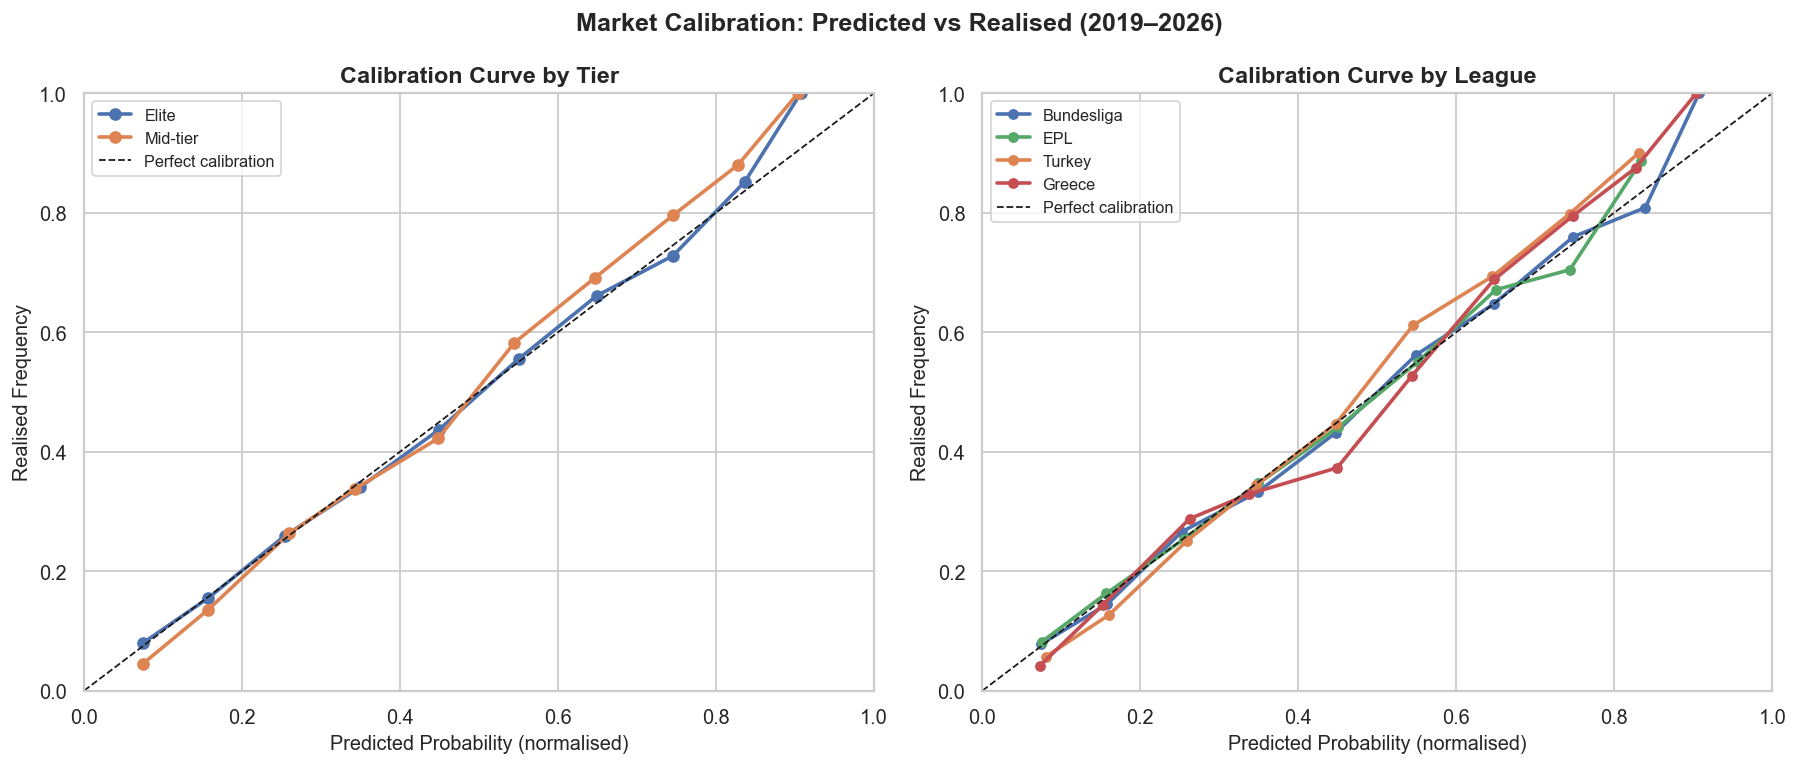

Points above diagonal = market underestimates that probability band
Points below diagonal = market overestimates that probability band


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bin into probability buckets and compute realised rate per bucket
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]

# Chart 1 — overall calibration by tier
for tier, color, label in zip(['elite', 'mid_tier'], ['#4C72B0', '#DD8452'], ['Elite', 'Mid-tier']):
    sub = long_df[long_df['tier'] == tier].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean'),
        n=('occurred', 'size')
    ).dropna()
    axes[0].plot(grouped['predicted'], grouped['realised'], marker='o',
                 color=color, label=label, linewidth=2, markersize=6)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_title('Calibration Curve by Tier', fontweight='bold')
axes[0].set_xlabel('Predicted Probability (normalised)')
axes[0].set_ylabel('Realised Frequency')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Chart 2 — calibration by league
for league, name, color in zip(['D1','E0','T1','G1'],
                                ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    sub = long_df[long_df['league'] == league].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean')
    ).dropna()
    axes[1].plot(grouped['predicted'], grouped['realised'], marker='o',
                 color=color, label=name, linewidth=2, markersize=5)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[1].set_title('Calibration Curve by League', fontweight='bold')
axes[1].set_xlabel('Predicted Probability (normalised)')
axes[1].set_ylabel('Realised Frequency')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

fig.suptitle('Market Calibration: Predicted vs Realised (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_calibration_curve.png', bbox_inches='tight')
plt.show()

# Points below the diagonal = overpredicted (outcome happens less than implied)
# Points above = underpredicted
print("Points above diagonal = market underestimates that probability band")
print("Points below diagonal = market overestimates that probability band")